# Calibration de prompt — Ajustement des parts modales
Optimise itérativement le prompt système pour approcher la distribution modale de l'EMC² 2023 Toulouse.

**Principe** : découper le prompt en blocs rationnels → évaluer sur 100 requêtes fixes → demander à Mistral de modifier
un seul bloc → garder si le score composite s'améliore → répéter 50 fois.

**Contrainte** : aucune mention de fréquences ou pourcentages de modes — uniquement des facteurs comportementaux.

In [1]:
import os, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

## 1 · Imports, configuration & module de calibration

Les fonctions réutilisables sont extraites dans [`prompt_calibration_lib.py`](prompt_calibration_lib.py) et importées via `from prompt_calibration_lib import *`. La cellule de chargement des données injecte ensuite la configuration dans le module avec `pcl.configure(...)`.

In [2]:
import sys, os, json, time, re, copy, random, threading
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime

import yaml
import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm.notebook import tqdm
from IPython.display import display, clear_output

from dotenv import load_dotenv
load_dotenv(Path("../../.env"))
sys.path.insert(0, str(Path("../..").resolve()))

from llm_module.adapters.base import get_adapter, ProviderClientError, ProviderServerError, ProviderParseError
from llm_module.settings.models import InternalMessage, InternalRequest
from llm_module.tasks.llm_config import get_batch_max_agents, settings  # capacité de batch + config providers

# Fonctions de calibration extraites dans prompt_calibration_lib.py
import prompt_calibration_lib as pcl
from prompt_calibration_lib import *

# ── Config ─────────────────────────────────────────────────────────────────
# Évaluation : Gemini (provider du llm_module). call_entry passe par get_adapter(EVAL_PROVIDER)
# sans forcer de modèle → le default_model du provider (providers.yaml) est utilisé.
EVAL_PROVIDER   = "google_gemini31"                # provider du llm_module (adapter google)
EVAL_MODEL      = "gemini-3.1-flash-lite-preview"  # modèle d'évaluation (= default_model du provider)
MUTATION_MODEL  = "gemini-3.1-flash-lite-preview"  # mutation AUSSI sur Gemini (plus d'abonnement Mistral)
SAMPLE_SIZE     = 100          # ↑ 10→40 pour réduire la variance statistique
MAX_ITERATIONS  = 29
SEED_PROMPT     = "expert"     # ignoré si USE_LAST_CHECKPOINT = True
USE_LAST_CHECKPOINT = False    # True → repart du meilleur checkpoint du dernier run
EVAL_RPM        = 15           # Gemini free tier : 15 req/min → ~4s/req. Le micro-batching
                               #    (cf. cellule suivante) réduit fortement le nb de requêtes.
EVAL_WORKERS    = 2            # = concurrency_limit du provider google_gemini31
MUTATION_TEMP   = 0.8
RANDOM_SEED     = 42
EVAL_TEMP       = 0.0         # #1 température au MINIMUM → décodage greedy, distribution ~déterministe.
                             #    La variance run-à-run du composite sur un même prompt s'effondre, ce qui
                             #    rend fiables les décisions accepter/rejeter du recuit (cause #1 d'instabilité).
EVAL_SAMPLES    = 3           # #1 nb de tirages par batch, mis en commun. À temp 0 le modèle n'est pas
                             #    strictement déterministe : 3 tirages absorbent le résidu de flips.
COLLATERAL_TOL  = 15.0        # #8 veto si une dimension non-globale se dégrade de +X pts L1 vs le meilleur
LENGTH_PENALTY_PER_WORD = 0.005  # poids (faible) de la pénalité longueur, comparée à 0 mot (≠ écart au prompt initial)

# Micro-batching : nb max de personas regroupées par requête LLM, lu depuis llm_config
# (max(1, min(tpm/tokens_par_agent, rpm, max_batch_agents)) — voir providers.yaml).
EVAL_BATCH_MAX  = get_batch_max_agents(EVAL_PROVIDER)

# Simulated annealing : accepter mutations légèrement moins bonnes en début de run
SA_T0           = 10.0        # température initiale
SA_ALPHA        = 0.92        # refroidissement par itération

# Recalcul global de l'ablation & early stopping
GLOBAL_ABLATION_EVERY = 10    # recalcul complet ablation toutes les K mutations acceptées
EARLY_STOP_PATIENCE   = 3    # nombre de checks val sans amélioration avant arrêt
VAL_FRACTION          = 0.20 # fraction d'eval_entries réservée à la validation (non vue pendant l'optim)

PROJECT_ROOT   = Path("../..")
EXCHANGES_FILE = PROJECT_ROOT / "experiments" / "current" / "llm_exchanges.jsonl"
SCHEMAS_FILE   = PROJECT_ROOT / "llm_module" / "prompts" / "schemas.json"
CEREMA_FILE    = PROJECT_ROOT / "scripts" / "data" / "population" / "cerema_values.yaml"
PROMPTS_FILE   = PROJECT_ROOT / "llm_module" / "prompts" / "prompts.yaml"
RESULTS_DIR    = Path("calibration_results")
RESULTS_DIR.mkdir(exist_ok=True)

# Clé Gemini : sert à l'évaluation (via l'adapter) ET à la génération de mutations.
GEMINI_API_KEY   = os.environ.get("PROVIDER_KEYS__google", "")
GEMINI_BASE_URL  = "https://generativelanguage.googleapis.com/v1beta"

# Modèle réellement appelé = default_model du provider (résolu depuis providers.yaml).
# Repli sur EVAL_MODEL si le provider est filtré (clé API absente de l'environnement).
try:
    EVAL_REAL_MODEL = settings.providers[EVAL_PROVIDER].default_model
except (KeyError, AttributeError):
    EVAL_REAL_MODEL = EVAL_MODEL
print(f"Modèle d'évaluation : provider={EVAL_PROVIDER!r} → {EVAL_REAL_MODEL!r}  "
      f"(batch_max={EVAL_BATCH_MAX}, temp={EVAL_TEMP}, samples={EVAL_SAMPLES})")
print(f"Modèle de mutation  : {MUTATION_MODEL!r}")
print(f"Clé Gemini : {'✅ présente' if GEMINI_API_KEY else '❌ MANQUANTE'}")


2026-06-29 12:24:55.830 | INFO     | llm_module.tasks.llm_config:build_providers:75 - Provider 'openai' — batch_max_agents=15 (tpm=200000, rpm=15, cap=20)
2026-06-29 12:24:55.831 | INFO     | llm_module.tasks.llm_config:build_providers:75 - Provider 'mistral' — batch_max_agents=20 (tpm=500000, rpm=90, cap=20)
2026-06-29 12:24:55.831 | INFO     | llm_module.tasks.llm_config:build_providers:75 - Provider 'google_gemini31' — batch_max_agents=15 (tpm=250000, rpm=15, cap=20)
2026-06-29 12:24:55.831 | INFO     | llm_module.tasks.llm_config:build_providers:75 - Provider 'google_gemma42' — batch_max_agents=15 (tpm=None, rpm=15, cap=20)
2026-06-29 12:24:55.831 | INFO     | llm_module.tasks.llm_config:build_providers:75 - Provider 'google_gemma43' — batch_max_agents=15 (tpm=None, rpm=15, cap=20)
2026-06-29 12:24:55.832 | INFO     | llm_module.tasks.llm_config:build_providers:75 - Provider 'groq_llama3' — batch_max_agents=1 (tpm=12000, rpm=30, cap=20)
2026-06-29 12:24:55.832 | INFO     | llm_modu

Modèle d'évaluation : provider='google_gemini31' → 'gemini-3.1-flash-lite-preview'  (batch_max=15, temp=0.0, samples=3)
Modèle de mutation  : 'gemini-3.1-flash-lite-preview'
Clé Gemini : ✅ présente


## 2 · Chargement des données & du prompt de départ

Sélection des requêtes d'évaluation, découpage train/val (early stopping), chargement de la référence EMC² 2023 et du prompt de départ (seed ou checkpoint), puis injection de la config dans le module.

In [3]:
CATEGORY = "itinary_multi_agent"

def parse_multiline_jsonl(path: Path) -> list[dict]:
    content = path.read_text(encoding="utf-8").strip()
    decoder = json.JSONDecoder()
    entries, pos = [], 0
    while pos < len(content):
        stripped = content[pos:].lstrip()
        pos += len(content[pos:]) - len(stripped)
        if not stripped:
            break
        obj, offset = decoder.raw_decode(stripped)
        entries.append(obj)
        pos += offset
    return entries

all_entries = parse_multiline_jsonl(EXCHANGES_FILE)
eligible = [
    e for e in all_entries
    if e.get("category") == CATEGORY
]
# Échantillon STRICTEMENT reproductible : seed fixe → toujours les mêmes requêtes,
# d'un run à l'autre et après tout redémarrage de la machine.
random.seed(RANDOM_SEED)
eval_entries = random.sample(eligible, min(SAMPLE_SIZE, len(eligible)))
print(f"Entrées sélectionnées : {len(eval_entries)} / {len(all_entries)}  (seed={RANDOM_SEED})")

# ── Découpage train / val (early stopping) ────────────────────────────────────
# val_entries : réservé à la détection d'overfitting, jamais vu pendant l'optimisation
n_val             = max(5, int(len(eval_entries) * VAL_FRACTION))
val_entries_raw   = eval_entries[:n_val]
train_entries_raw = eval_entries[n_val:]
print(f"  Entrées brutes — Train : {len(train_entries_raw)}  |  Val : {len(val_entries_raw)}")

# ── Micro-batching : regrouper les personas en lots ≤ EVAL_BATCH_MAX ──
# Les entrées enregistrées sont majoritairement mono-persona ; une requête par entrée serait
# prohibitif à 15 RPM (Gemini). La météo de chaque entrée est injectée DANS son bloc persona,
# si bien que des personas de météos différentes peuvent cohabiter dans un même lot : les lots
# se remplissent jusqu'à EVAL_BATCH_MAX (lu depuis llm_config) au lieu de ~2/lot. Train et val
# sont batchés séparément → aucune fuite de personas. Les agent_id restent inscrits dans chaque
# lot, donc METADATA_CACHE (construit sur eval_entries) demeure valide.
train_entries = build_micro_batches(train_entries_raw, EVAL_BATCH_MAX)
val_entries   = build_micro_batches(val_entries_raw, EVAL_BATCH_MAX)
print(f"  Micro-batches (≤{EVAL_BATCH_MAX} personas/req) — Train : {len(train_entries)} lots  |  Val : {len(val_entries)} lots")

with open(CEREMA_FILE) as f:
    cerema = yaml.safe_load(f)
print(f"Référence globale EMC² 2023 : {cerema['parts_modales_2023']['global']}")

with open(SCHEMAS_FILE) as f:
    RESPONSE_SCHEMA = json.load(f)[CATEGORY]

with open(PROMPTS_FILE) as f:
    prompts_db = yaml.safe_load(f)

# ── Chargement du prompt de départ ───────────────────────────────────────────
_checkpoint_file = RESULTS_DIR / "best_checkpoint.yaml"
if USE_LAST_CHECKPOINT and _checkpoint_file.exists():
    with open(_checkpoint_file) as f:
        _ckpt = yaml.safe_load(f)
    INITIAL_PROMPT_TEXT = _ckpt["content"]
    _ckpt_meta = _ckpt.get("_calibration", {})
    SEED_PROMPT = f"last_checkpoint (seed={_ckpt_meta.get('seed','?')}, score={_ckpt_meta.get('score_best','?')})"
    # Sauvegarde du checkpoint dans prompts.yaml avant qu'il soit écrasé par le nouveau run
    _archive_key = f"checkpoint_{datetime.now().strftime('%Y%m%d_%H%M')}"
    prompts_db["prompts"][_archive_key] = {
        "content": INITIAL_PROMPT_TEXT,
        "_calibration": {**_ckpt_meta, "archived_at": datetime.now().isoformat(timespec="seconds")},
    }
    with open(PROMPTS_FILE, "w") as f:
        yaml.dump(prompts_db, f, allow_unicode=True, default_flow_style=False, sort_keys=False)
    print(f"Prompt de départ : checkpoint archivé sous {_archive_key!r}")
elif USE_LAST_CHECKPOINT:
    print(f"⚠ Pas de checkpoint trouvé ({_checkpoint_file}) — repli sur SEED_PROMPT={SEED_PROMPT!r}")
    INITIAL_PROMPT_TEXT = prompts_db["prompts"][SEED_PROMPT]["content"]
else:
    INITIAL_PROMPT_TEXT = prompts_db["prompts"][SEED_PROMPT]["content"]

INITIAL_PROMPT_WORD_COUNT = len(INITIAL_PROMPT_TEXT.split())
print(f"Prompt de départ : {SEED_PROMPT!r}  ({INITIAL_PROMPT_WORD_COUNT} mots)")

# ── Injection de la configuration dans le module de calibration ──────────────
pcl.configure(
    EVAL_PROVIDER=EVAL_PROVIDER, EVAL_MODEL=EVAL_MODEL, EVAL_TEMP=EVAL_TEMP,
    EVAL_SAMPLES=EVAL_SAMPLES, EVAL_RPM=EVAL_RPM, EVAL_WORKERS=EVAL_WORKERS,
    MUTATION_MODEL=MUTATION_MODEL, MUTATION_TEMP=MUTATION_TEMP,
    GEMINI_API_KEY=GEMINI_API_KEY, GEMINI_BASE_URL=GEMINI_BASE_URL,
    RESPONSE_SCHEMA=RESPONSE_SCHEMA, cerema=cerema,
    INITIAL_PROMPT_WORD_COUNT=INITIAL_PROMPT_WORD_COUNT,
    LENGTH_PENALTY_PER_WORD=LENGTH_PENALTY_PER_WORD,
    RESULTS_DIR=RESULTS_DIR, EVAL_CACHE_DIR=RESULTS_DIR / "eval_cache",
)
print("Configuration injectée dans prompt_calibration_lib")

# ── Manifeste de run : verrouille l'échantillon/la config & détecte un cache périmé ──
# Tous les résultats (eval_cache/, mutations.jsonl) sont rattachés à CETTE configuration.
# Si l'on relance avec un seed, un prompt de départ, un échantillon ou un modèle différents,
# les caches du run précédent ne correspondent plus : on le signale clairement plutôt que de
# rejouer par erreur d'anciens résultats. Identique → la reprise depuis le cache est validée.
import hashlib
RUN_MANIFEST_FILE = RESULTS_DIR / "run_manifest.json"

def _hash_text(t: str) -> str:
    return hashlib.sha256(t.encode("utf-8")).hexdigest()[:16]

current_manifest = {
    "random_seed":         RANDOM_SEED,
    "sample_size":         SAMPLE_SIZE,
    "seed_prompt":         SEED_PROMPT,
    "eval_provider":       EVAL_PROVIDER,
    "eval_model":          EVAL_REAL_MODEL,
    "eval_temp":           EVAL_TEMP,
    "eval_samples":        EVAL_SAMPLES,
    "initial_prompt_hash": _hash_text(INITIAL_PROMPT_TEXT),
    "train_hash":          _hash_text("".join(b["messages"][1]["content"] for b in train_entries)),
    "val_hash":            _hash_text("".join(b["messages"][1]["content"] for b in val_entries)),
}

if RUN_MANIFEST_FILE.exists():
    prev_manifest = json.loads(RUN_MANIFEST_FILE.read_text(encoding="utf-8"))
    diff = {k: (prev_manifest.get(k), current_manifest[k])
            for k in current_manifest if prev_manifest.get(k) != current_manifest[k]}
    if diff:
        print("⚠ MANIFESTE DIFFÉRENT du run précédent — les caches risquent d'être périmés :")
        for k, (old, new) in diff.items():
            print(f"    {k}: {old!r} → {new!r}")
        print("  → vide calibration_results/eval_cache/ et mutations.jsonl pour repartir proprement.")
    else:
        print("✅ Manifeste identique au run précédent — reprise transparente depuis le cache validée.")
else:
    print("ℹ Nouveau manifeste de run créé (premier run pour cette configuration).")

RUN_MANIFEST_FILE.write_text(json.dumps(current_manifest, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"   Manifeste → {RUN_MANIFEST_FILE}")


Entrées sélectionnées : 100 / 716  (seed=42)
  Entrées brutes — Train : 80  |  Val : 20
  Micro-batches (≤15 personas/req) — Train : 13 lots  |  Val : 3 lots
Référence globale EMC² 2023 : {'voiture': 55, 'marche': 26, 'transports_collectifs': 12, 'velo': 4, 'autres_modes': 3}
Prompt de départ : 'expert'  (335 mots)
Configuration injectée dans prompt_calibration_lib
✅ Manifeste identique au run précédent — reprise transparente depuis le cache validée.
   Manifeste → calibration_results/run_manifest.json


## 3 · Extraction des métadonnées persona

Pour chaque agent : âge, occupation, genre (inféré du prénom), motif et distance — utilisés pour scorer la distribution modale par strate vs EMC².

In [4]:
# Métadonnées persona — fonctions dans prompt_calibration_lib.py
METADATA_CACHE = build_metadata_cache(eval_entries)
occ_counts   = pd.Series([v["occupation"] for v in METADATA_CACHE.values()]).value_counts()
genre_counts = pd.Series([v["genre"]      for v in METADATA_CACHE.values()]).value_counts()
motif_counts = pd.Series([v["motif"]      for v in METADATA_CACHE.values()]).value_counts()
dist_counts  = pd.Series([v["dist_cat"]   for v in METADATA_CACHE.values()]).value_counts()
print(f"Métadonnées extraites : {len(METADATA_CACHE)} agents")
print(f"Occupations :\n{occ_counts.to_string()}")
print(f"\nGenre :\n{genre_counts.to_string()}")
print(f"\nMotifs :\n{motif_counts.to_string()}")
print(f"\nDistances :\n{dist_counts.to_string()}")


Métadonnées extraites : 10 agents
Occupations :
autre                       3
etudiant                    2
chomeur_recherche_emploi    2
Retraité                    1
actif_temps_partiel         1
scolaire                    1

Genre :
Femme    6
Homme    4

Motifs :
travail    2
achats     1
etudes     1

Distances :
10-20km    3
1-2km      3
5-10km     2
2-5km      1
20-50km    1


## 4 · Décomposition du prompt en blocs

Le prompt est découpé en blocs au niveau phrase (le schéma JSON reste non-mutable). Chaque bloc devient une unité mutable indépendante. Une vérification aller-retour garantit qu'aucun contenu n'est perdu.

In [5]:
# Décomposition du prompt en blocs — fonctions dans prompt_calibration_lib.py
initial_blocks = decompose_prompt(INITIAL_PROMPT_TEXT)
print(f"Blocs identifiés : {len(initial_blocks)}")
print(f"  Modifiables : {[b['name'] for b in initial_blocks if b['mutable']]}")
print(f"  Fixes       : {[b['name'] for b in initial_blocks if not b['mutable']]}")
display_blocks(initial_blocks)

# Vérification aller-retour : normalise les espaces/sauts de ligne avant comparaison
# (la décomposition phrase par phrase reformate les sauts internes, le contenu est identique)
def _norm_ws(s: str) -> str:
    return re.sub(r'\s+', ' ', s).strip()

reconstructed = blocks_to_prompt(initial_blocks)
assert _norm_ws(reconstructed) == _norm_ws(INITIAL_PROMPT_TEXT), (
    f"⚠ Contenu perdu lors de la décomposition !\n"
    f"Reconstruit : {_norm_ws(reconstructed)[:300]}\n"
    f"Original    : {_norm_ws(INITIAL_PROMPT_TEXT)[:300]}"
)
print(f"\n✅ Aller-retour OK — {len(initial_blocks)} blocs")


Blocs identifiés : 11
  Modifiables : ['consigne_s1', 'consigne_s2', 'consigne_s3', 'bullet_1', 'bullet_2', 'bullet_3', 'bullet_4', 'bullet_5', 'consigne_s4', 'intro_s1']
  Fixes       : ['json_schema']
═════════════════════════════════════════════════════════════════

✏  [consigne_s1]
────────────────────────────────────────
Tu vas incarner séquentiellement des personnes vivant à Toulouse.

✏  [consigne_s2]
────────────────────────────────────────
Ta tâche est de sélectionner le mode de déplacement optimal.

✏  [consigne_s3]
────────────────────────────────────────
L'évaluation doit être purement algorithmique et s'effectuer en 4 étapes :
1) Filtrage strict : Définis les lignes rouges non négociables du persona pour éliminer d'emblée les options invalides.
2) Matrice de coût : Calcule le véritable coût d'opportunité de chaque option en pondérant les variables suivantes exclusivement selon les attributs du profil (âge, revenus, santé) :

✏  [bullet_1]
──────────────────────────────────

## 5 · Run initial & ablation de référence

Évaluation du prompt de départ (score composite + distribution), puis **ablation** : on retire chaque bloc un par un pour mesurer son impact. Δ>0 ⇒ bloc UTILE (le retirer dégrade) ; Δ<0 ⇒ bloc NUISIBLE (le retirer améliore). Pour les blocs nuisibles, le diagnostic remonte la dimension L1 et le mode EMC² responsables.

▶ Évaluation initiale du prompt 'expert' sur le jeu train (63 personas regroupés en 13 lots, soit 4.8 personas/lot)…
  ↺ retrieved from previous session — Run initial (66 décisions, key=f6367ab54eb81650)

Score initial — composite=383.57  (global=75.3  âge=98.9  occupation=118.3  genre=75.6  motif=55.7  distance=58.3)


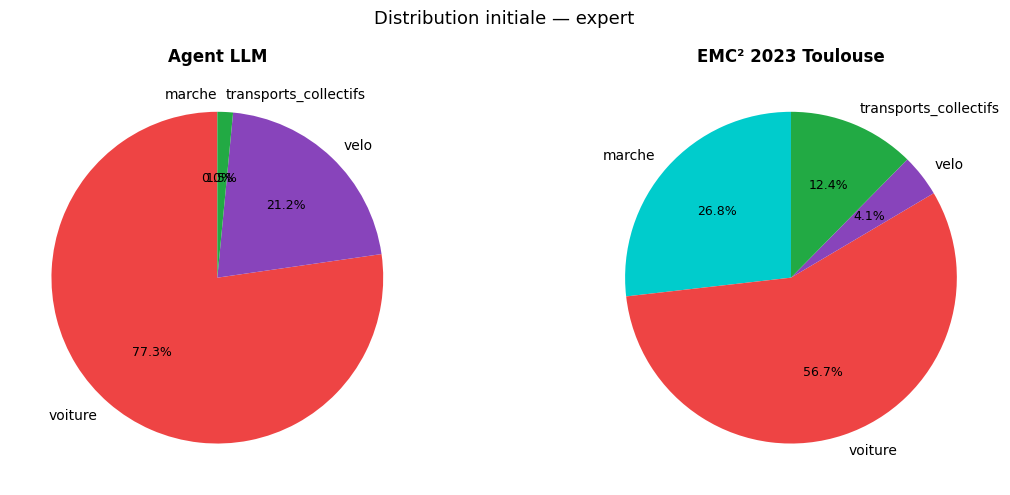


═════════════════════════════════════════════════════════════════
▶ Ablation initiale — identification des blocs utiles/nuisibles…
  (Δ > 0 : bloc UTILE — la suppression dégrade)
  (Δ < 0 : bloc NUISIBLE — la suppression améliore)
═════════════════════════════════════════════════════════════════
  ↺ retrieved from previous session — Ablation init [consigne_s1] (75 décisions, key=51beffc17e312631)
  consigne_s1             Δ= +15.28  🔑 UTILE     — supprimer ↑ dégrade  → garder
    ↳ Tu vas incarner séquentiellement des personnes vivant à Toulouse.
  ↺ retrieved from previous session — Ablation init [consigne_s2] (83 décisions, key=64865058f0fb106d)
  consigne_s2             Δ= -62.46  🗑  NUISIBLE — supprimer ↓ améliore → réécrire/supprimer
    ↳ régression : dim occupation -13.9, age -8.1 · sur-pousse velo (+17→+10 pts vs cible)
    ↳ Ta tâche est de sélectionner le mode de déplacement optimal.
  ↺ retrieved from previous session — Ablation init [consigne_s3] (66 décisions, key=9268bc5

In [6]:
# ── Run initial ──────────────────────────────────────────────────────────────
current_blocks = copy.deepcopy(initial_blocks)
best_blocks    = copy.deepcopy(initial_blocks)
best_score     = None
best_scores    = None   # dict complet des scores (pour dim_scores dans generate_mutation)
best_df        = None
history        = []

initial_prompt = blocks_to_prompt(current_blocks)
# Nombre de personas (messages) effectivement regroupés dans les micro-batches du jeu train
n_personas_train = sum(len(split_entry_personas(b["messages"][1]["content"])[1]) for b in train_entries)
print(f"▶ Évaluation initiale du prompt {SEED_PROMPT!r} sur le jeu train "
      f"({n_personas_train} personas regroupés en {len(train_entries)} lots, "
      f"soit {n_personas_train / len(train_entries):.1f} personas/lot)…")
df_init     = run_evaluation(train_entries, initial_prompt, METADATA_CACHE, desc="Run initial")
init_scores = compute_composite_score(df_init, cerema, prompt_text=initial_prompt)
best_score  = init_scores["composite"]
best_scores = init_scores
best_df     = df_init

# Meilleur score toutes itérations confondues (indépendant du SA)
all_time_best_score  = best_score
all_time_best_blocks = copy.deepcopy(best_blocks)
all_time_best_df     = df_init

print(f"\nScore initial — composite={best_score:.2f}  "
      f"(global={init_scores['global']:.1f}  "
      f"âge={init_scores['age']:.1f}  "
      f"occupation={init_scores['occupation']:.1f}  "
      f"genre={init_scores['genre']:.1f}  "
      f"motif={init_scores['motif']:.1f}  "
      f"distance={init_scores['distance']:.1f})")

history.append({"iteration": 0, "scores": init_scores, "best_score": best_score,
                "kept": True, "mutation": None,
                "prompt": initial_prompt})

plot_distribution_pies(df_init, f"Distribution initiale — {SEED_PROMPT}")

print("\n" + "═" * 65)
print("▶ Ablation initiale — identification des blocs utiles/nuisibles…")
print("  (Δ > 0 : bloc UTILE — la suppression dégrade)")
print("  (Δ < 0 : bloc NUISIBLE — la suppression améliore)")
print("═" * 65)
ablation_init = run_ablation(initial_blocks, train_entries, METADATA_CACHE, cerema,
                             best_score, ref_scores=init_scores, ref_df=df_init,
                             label="Ablation init")

### Carte d'ablation du prompt initial


═════════════════════════════════════════════════════════════════
  Run initial — expert
═════════════════════════════════════════════════════════════════

CARTE D'ABLATION   vert=utile · rouge=nuisible



⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · marche                 : -28.6 pts (sous-represente, actuel=0% cible=29%, n=54)
  age[20-24] · velo                   : +54.2 pts (sur-represente, actuel=58% cible=4%, n=24)
  occupation[etudiant] · velo                   : +47.8 pts (sur-represente, actuel=52% cible=4%, n=27)
  genre[Femme] · velo                   : +22.9 pts (sur-represente, actuel=26% cible=3%, n=54)
  distance[1-2km] · velo                   : +45.7 pts (sur-represente, actuel=52% cible=6%, n=27)
  occupation[etudiant] · transports_collectifs  : -41.4 pts (sous-represente, actuel=0% cible=41%, n=27)


★ Score global (composite L1, ↓ mieux) : 383.57

Scores L1 par dimension (↓ mieux, contribution = L1 × poids) :
  global                L1= 75.3  ×1.0  →  75.3  ████████████████████
  age                   L1= 98.9  ×0.5  →  49.4  ████████████████████
  occupation            L1=118.3  ×0.5  →  59.2  ████████████████████

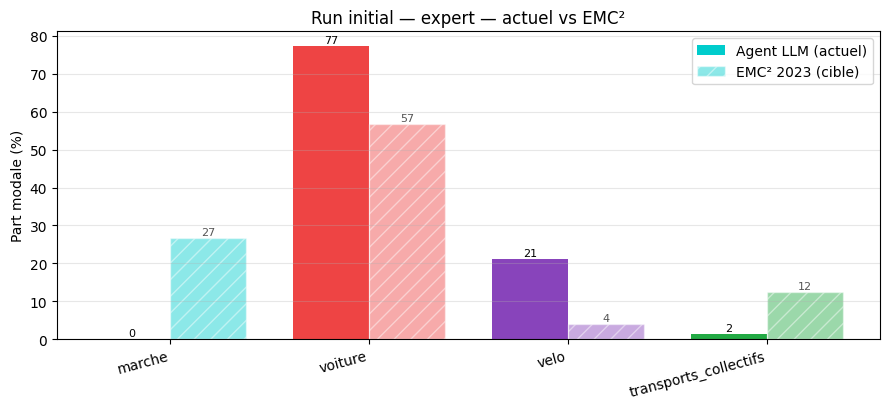

In [7]:
# Tableau de bord du run initial — fonction dans prompt_calibration_lib.py
present_calibration_state(
    initial_blocks, ablation_init, df_init, init_scores,
    history=history, title=f"Run initial — {SEED_PROMPT}", show_history=False,
)

## 6 · Boucle d'optimisation (recuit simulé + ablation incrémentale)

À chaque itération : Mistral propose une mutation d'un bloc → évaluation sur le jeu train → veto si une dimension non-globale se dégrade trop → acceptation par recuit simulé. À chaque mutation acceptée, l'ablation du bloc touché est recalculée localement ; un **recalcul global** complet a lieu toutes les `GLOBAL_ABLATION_EVERY` mutations *acceptées* (pas toutes les itérations). Validation + early stopping tous les 5 tours.


═════════════════════════════════════════════════════════════════
  Itération  1/50  |  Meilleur score : 383.57  |  🏆 All-time best : 383.57  |  T=9.20
═════════════════════════════════════════════════════════════════

── user_msg envoyé au LLM de mutation ──
Distribution LLM actuelle (66 décisions) :
  marche: 0.0%  (cible EMC²: 26%)
  voiture: 77.3%  (cible EMC²: 55%)
  velo: 21.2%  (cible EMC²: 4%)
  transports_collectifs: 1.5%  (cible EMC²: 12%)

Écarts vs EMC² 2023 :
  marche sous-représenté de 26.0 pts
  voiture sur-représenté de 22.3 pts
  velo sur-représenté de 17.2 pts
  transports_collectifs sous-représenté de 10.5 pts

⚠️ DEUX leviers prioritaires (les deux comptent autant) :
  • RENFORCER : marche (ABSENT) (actuel=0.0%, cible=26%, manque +26.0 pts)
  • ATTÉNUER  : voiture (actuel=77.3%, cible=55%, excès +22.3 pts)

⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · marche                 : -28.6 pts (sous-represente, actuel=0% 

Itération 1:   0%|          | 0/39 [00:00<?, ?it/s]

  Rate limit → 17s
  Rate limit → 12s
  💾 Checkpoint → best_checkpoint.yaml  (score=202.47, iter=1)
  🏆 Nouveau meilleur score toutes itérations : 202.47
  ↺ retrieved from previous session — Ablation [bullet_4] (66 décisions, key=375a026db5687dcf)
  bullet_4                Δ= +27.79  🔑 UTILE
    ↳ - Filtre de réalité : Priorise les modes actifs pour les déplacements de proximité et intègre la lourdeur des …

  ✅ AMÉLIORÉ  202.47  (Δ=-181.10  absent_penalty=0  length_penalty=1.7)
    global=65.0  âge=86.9  occupation=109.2  genre=67.9  motif=0.0  distance=57.7

═════════════════════════════════════════════════════════════════
  Itération 1 — ✅ AMÉLIORÉ
═════════════════════════════════════════════════════════════════

CARTE D'ABLATION   vert=utile · rouge=nuisible



⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%, n=50)
  genre[Femme] · marche                 : -22.6 pts (sous-represente, actuel=6% cible=29%, n=50)
  age[75-130] · voiture                : +50.0 pts (sur-represente, actuel=100% cible=50%, n=21)
  occupation[etudiant] · voiture                : +41.8 pts (sur-represente, actuel=60% cible=18%, n=25)
  occupation[etudiant] · transports_collectifs  : -41.4 pts (sous-represente, actuel=0% cible=41%, n=25)
  occupation[Retraité] · voiture                : +43.4 pts (sur-represente, actuel=100% cible=57%, n=21)


★ Score global (composite L1, ↓ mieux) : 202.47

Scores L1 par dimension (↓ mieux, contribution = L1 × poids) :
  global                L1= 65.0  ×1.0  →  65.0  ████████████████████
  age                   L1= 86.9  ×0.5  →  43.4  ████████████████████
  occupation            L1=109.2  ×0.5  →  54.6  ████████

/Users/yvesb/Documents/llm-agents-gama/scripts/models_influence/prompt_calibration_lib.py:1310: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yvesb/Documents/llm-agents-gama/llm-agents/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


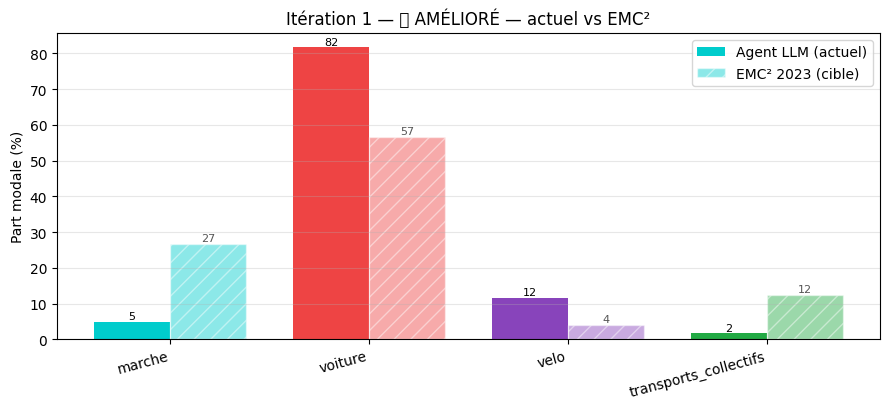

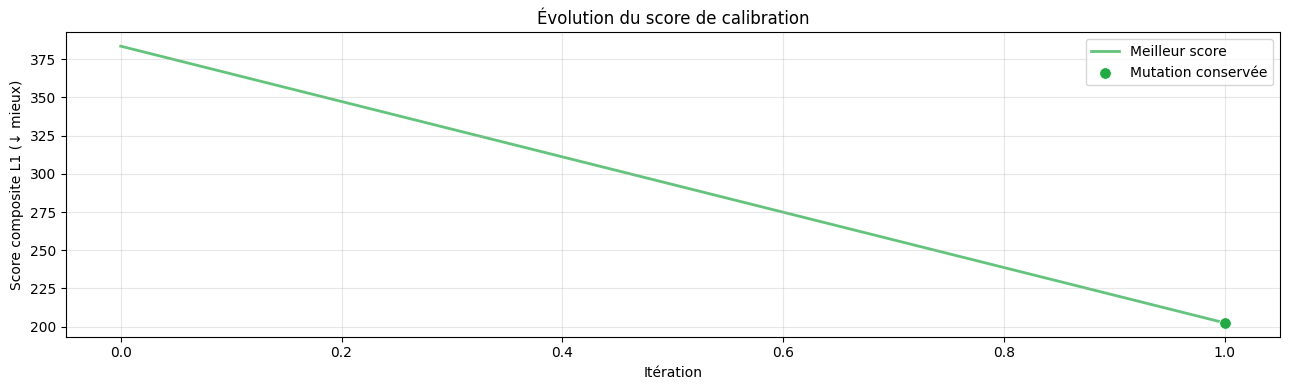

═════════════════════════════════════════════════════════════════
  Itération  2/50  |  Meilleur score : 202.47  |  🏆 All-time best : 202.47  |  T=8.46
═════════════════════════════════════════════════════════════════

── user_msg envoyé au LLM de mutation ──
Distribution LLM actuelle (60 décisions) :
  marche: 5.0%  (cible EMC²: 26%)
  voiture: 81.7%  (cible EMC²: 55%)
  velo: 11.7%  (cible EMC²: 4%)
  transports_collectifs: 1.7%  (cible EMC²: 12%)

Écarts vs EMC² 2023 :
  marche sous-représenté de 21.0 pts
  voiture sur-représenté de 26.7 pts
  velo sur-représenté de 7.7 pts
  transports_collectifs sous-représenté de 10.3 pts

⚠️ DEUX leviers prioritaires (les deux comptent autant) :
  • RENFORCER : marche (actuel=5.0%, cible=26%, manque +21.0 pts)
  • ATTÉNUER  : voiture (actuel=81.7%, cible=55%, excès +26.7 pts)

⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%,

Itération 2:   0%|          | 0/39 [00:00<?, ?it/s]

  Rate limit → 18s
  Rate limit → 14s
  ⛔ Veto collatéral — dimension(s) dégradée(s) de >15 pts : motif +94

  ⛔ VETO  247.55  (Δ=+45.09  absent_penalty=0  length_penalty=1.9)
    global=64.7  âge=92.2  occupation=93.0  genre=69.1  motif=93.8  distance=69.0

═════════════════════════════════════════════════════════════════
  Itération 2 — ⛔ VETO
═════════════════════════════════════════════════════════════════

CARTE D'ABLATION   vert=utile · rouge=nuisible



⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%, n=50)
  genre[Femme] · marche                 : -22.6 pts (sous-represente, actuel=6% cible=29%, n=50)
  age[75-130] · voiture                : +50.0 pts (sur-represente, actuel=100% cible=50%, n=21)
  occupation[etudiant] · voiture                : +41.8 pts (sur-represente, actuel=60% cible=18%, n=25)
  occupation[etudiant] · transports_collectifs  : -41.4 pts (sous-represente, actuel=0% cible=41%, n=25)
  occupation[Retraité] · voiture                : +43.4 pts (sur-represente, actuel=100% cible=57%, n=21)


★ Score global (composite L1, ↓ mieux) : 202.47

Scores L1 par dimension (↓ mieux, contribution = L1 × poids) :
  global                L1= 65.0  ×1.0  →  65.0  ████████████████████
  age                   L1= 86.9  ×0.5  →  43.4  ████████████████████
  occupation            L1=109.2  ×0.5  →  54.6  ████████

/Users/yvesb/Documents/llm-agents-gama/scripts/models_influence/prompt_calibration_lib.py:1310: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yvesb/Documents/llm-agents-gama/llm-agents/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


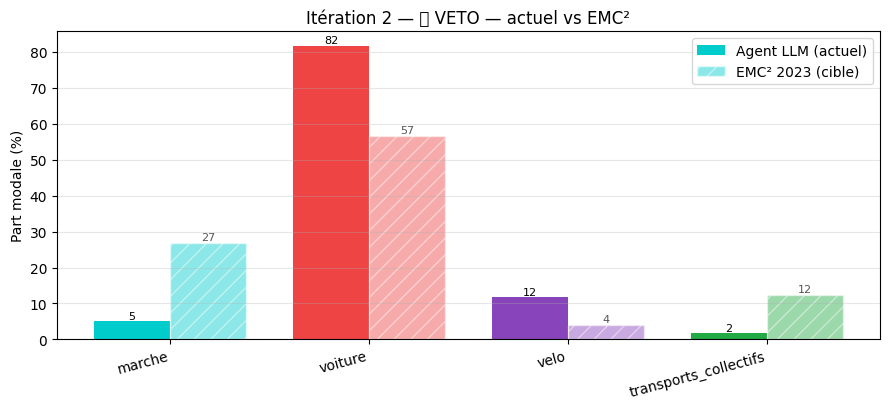

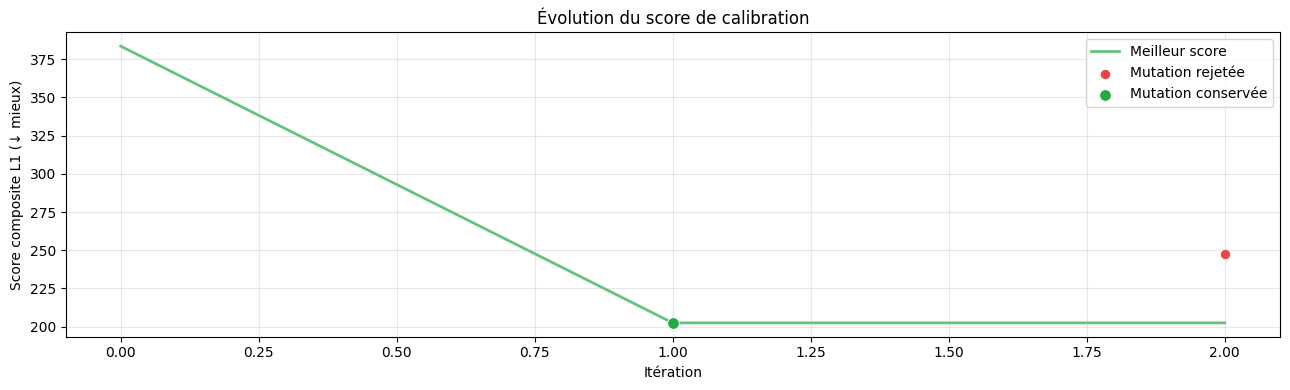

═════════════════════════════════════════════════════════════════
  Itération  3/50  |  Meilleur score : 202.47  |  🏆 All-time best : 202.47  |  T=7.79
═════════════════════════════════════════════════════════════════

── user_msg envoyé au LLM de mutation ──
Distribution LLM actuelle (60 décisions) :
  marche: 5.0%  (cible EMC²: 26%)
  voiture: 81.7%  (cible EMC²: 55%)
  velo: 11.7%  (cible EMC²: 4%)
  transports_collectifs: 1.7%  (cible EMC²: 12%)

Écarts vs EMC² 2023 :
  marche sous-représenté de 21.0 pts
  voiture sur-représenté de 26.7 pts
  velo sur-représenté de 7.7 pts
  transports_collectifs sous-représenté de 10.3 pts

⚠️ DEUX leviers prioritaires (les deux comptent autant) :
  • RENFORCER : marche (actuel=5.0%, cible=26%, manque +21.0 pts)
  • ATTÉNUER  : voiture (actuel=81.7%, cible=55%, excès +26.7 pts)

⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%,

Itération 3:   0%|          | 0/39 [00:00<?, ?it/s]

  ⛔ Veto collatéral — dimension(s) dégradée(s) de >15 pts : motif +41

  ⛔ VETO  219.18  (Δ=+16.71  absent_penalty=0  length_penalty=1.9)
    global=59.4  âge=97.3  occupation=104.2  genre=63.7  motif=41.2  distance=57.9

═════════════════════════════════════════════════════════════════
  Itération 3 — ⛔ VETO
═════════════════════════════════════════════════════════════════

CARTE D'ABLATION   vert=utile · rouge=nuisible



⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%, n=50)
  genre[Femme] · marche                 : -22.6 pts (sous-represente, actuel=6% cible=29%, n=50)
  age[75-130] · voiture                : +50.0 pts (sur-represente, actuel=100% cible=50%, n=21)
  occupation[etudiant] · voiture                : +41.8 pts (sur-represente, actuel=60% cible=18%, n=25)
  occupation[etudiant] · transports_collectifs  : -41.4 pts (sous-represente, actuel=0% cible=41%, n=25)
  occupation[Retraité] · voiture                : +43.4 pts (sur-represente, actuel=100% cible=57%, n=21)


★ Score global (composite L1, ↓ mieux) : 202.47

Scores L1 par dimension (↓ mieux, contribution = L1 × poids) :
  global                L1= 65.0  ×1.0  →  65.0  ████████████████████
  age                   L1= 86.9  ×0.5  →  43.4  ████████████████████
  occupation            L1=109.2  ×0.5  →  54.6  ████████

/Users/yvesb/Documents/llm-agents-gama/scripts/models_influence/prompt_calibration_lib.py:1310: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yvesb/Documents/llm-agents-gama/llm-agents/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


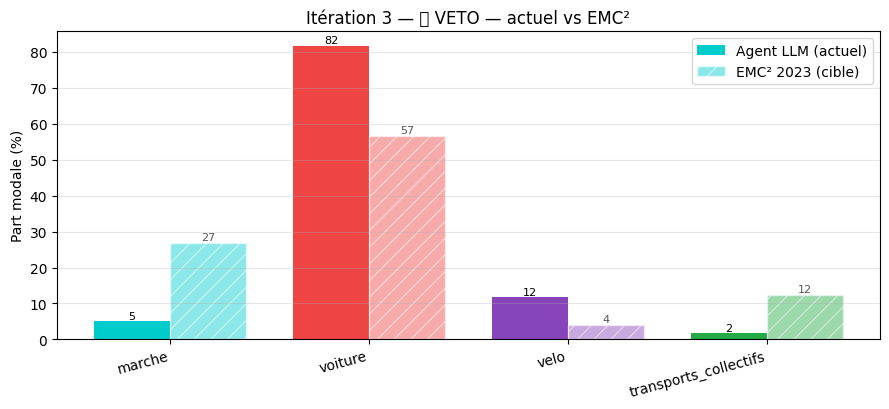

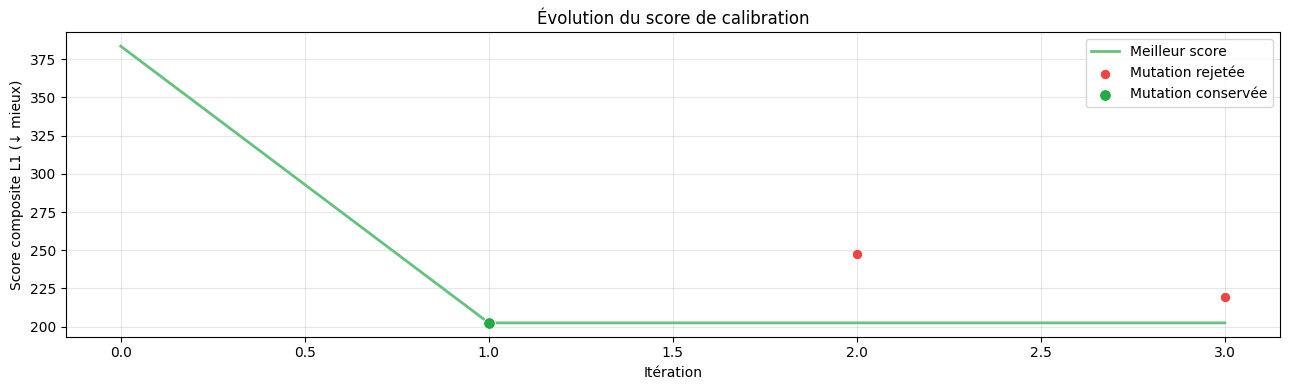

═════════════════════════════════════════════════════════════════
  Itération  4/50  |  Meilleur score : 202.47  |  🏆 All-time best : 202.47  |  T=7.16
═════════════════════════════════════════════════════════════════

── user_msg envoyé au LLM de mutation ──
Distribution LLM actuelle (60 décisions) :
  marche: 5.0%  (cible EMC²: 26%)
  voiture: 81.7%  (cible EMC²: 55%)
  velo: 11.7%  (cible EMC²: 4%)
  transports_collectifs: 1.7%  (cible EMC²: 12%)

Écarts vs EMC² 2023 :
  marche sous-représenté de 21.0 pts
  voiture sur-représenté de 26.7 pts
  velo sur-représenté de 7.7 pts
  transports_collectifs sous-représenté de 10.3 pts

⚠️ DEUX leviers prioritaires (les deux comptent autant) :
  • RENFORCER : marche (actuel=5.0%, cible=26%, manque +21.0 pts)
  • ATTÉNUER  : voiture (actuel=81.7%, cible=55%, excès +26.7 pts)

⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%,

Itération 4:   0%|          | 0/39 [00:00<?, ?it/s]

  ⛔ Veto collatéral — dimension(s) dégradée(s) de >15 pts : motif +104, distance +21

  ⛔ VETO  233.52  (Δ=+31.05  absent_penalty=0  length_penalty=1.9)
    global=54.5  âge=89.7  occupation=76.4  genre=61.9  motif=103.6  distance=78.9

═════════════════════════════════════════════════════════════════
  Itération 4 — ⛔ VETO
═════════════════════════════════════════════════════════════════

CARTE D'ABLATION   vert=utile · rouge=nuisible



⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%, n=50)
  genre[Femme] · marche                 : -22.6 pts (sous-represente, actuel=6% cible=29%, n=50)
  age[75-130] · voiture                : +50.0 pts (sur-represente, actuel=100% cible=50%, n=21)
  occupation[etudiant] · voiture                : +41.8 pts (sur-represente, actuel=60% cible=18%, n=25)
  occupation[etudiant] · transports_collectifs  : -41.4 pts (sous-represente, actuel=0% cible=41%, n=25)
  occupation[Retraité] · voiture                : +43.4 pts (sur-represente, actuel=100% cible=57%, n=21)


★ Score global (composite L1, ↓ mieux) : 202.47

Scores L1 par dimension (↓ mieux, contribution = L1 × poids) :
  global                L1= 65.0  ×1.0  →  65.0  ████████████████████
  age                   L1= 86.9  ×0.5  →  43.4  ████████████████████
  occupation            L1=109.2  ×0.5  →  54.6  ████████

/Users/yvesb/Documents/llm-agents-gama/scripts/models_influence/prompt_calibration_lib.py:1310: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yvesb/Documents/llm-agents-gama/llm-agents/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


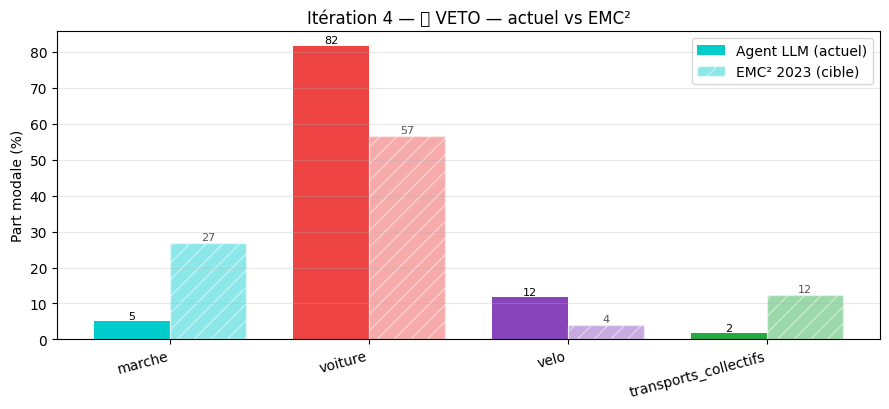

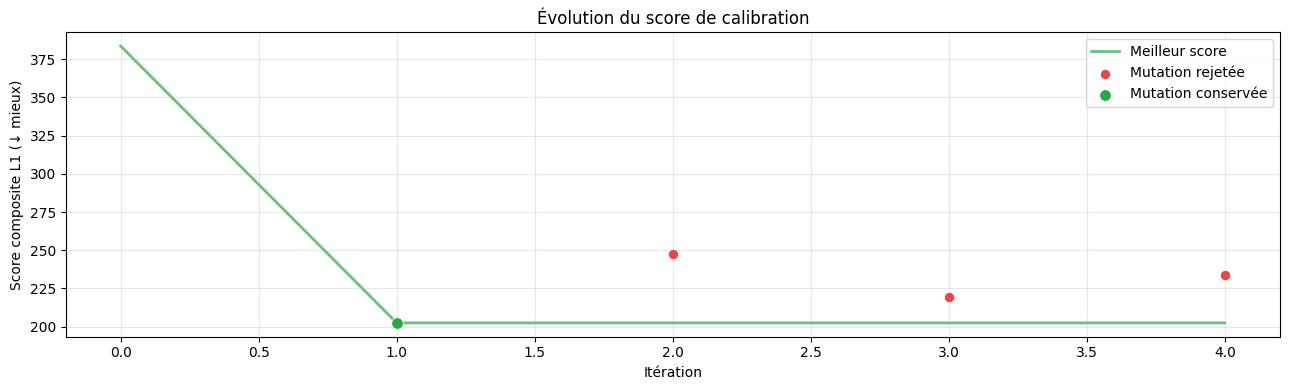

═════════════════════════════════════════════════════════════════
  Itération  5/50  |  Meilleur score : 202.47  |  🏆 All-time best : 202.47  |  T=6.59
═════════════════════════════════════════════════════════════════

── user_msg envoyé au LLM de mutation ──
Distribution LLM actuelle (60 décisions) :
  marche: 5.0%  (cible EMC²: 26%)
  voiture: 81.7%  (cible EMC²: 55%)
  velo: 11.7%  (cible EMC²: 4%)
  transports_collectifs: 1.7%  (cible EMC²: 12%)

Écarts vs EMC² 2023 :
  marche sous-représenté de 21.0 pts
  voiture sur-représenté de 26.7 pts
  velo sur-représenté de 7.7 pts
  transports_collectifs sous-représenté de 10.3 pts

⚠️ DEUX leviers prioritaires (les deux comptent autant) :
  • RENFORCER : marche (actuel=5.0%, cible=26%, manque +21.0 pts)
  • ATTÉNUER  : voiture (actuel=81.7%, cible=55%, excès +26.7 pts)

⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%,

Itération 5:   0%|          | 0/39 [00:00<?, ?it/s]

  ⛔ Veto collatéral — dimension(s) dégradée(s) de >15 pts : motif +94

  ⛔ VETO  250.29  (Δ=+47.82  absent_penalty=0  length_penalty=1.9)
    global=67.2  âge=91.9  occupation=100.2  genre=69.5  motif=93.8  distance=57.8

═════════════════════════════════════════════════════════════════
  Itération 5 — ⛔ VETO
═════════════════════════════════════════════════════════════════

CARTE D'ABLATION   vert=utile · rouge=nuisible



⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%, n=50)
  genre[Femme] · marche                 : -22.6 pts (sous-represente, actuel=6% cible=29%, n=50)
  age[75-130] · voiture                : +50.0 pts (sur-represente, actuel=100% cible=50%, n=21)
  occupation[etudiant] · voiture                : +41.8 pts (sur-represente, actuel=60% cible=18%, n=25)
  occupation[etudiant] · transports_collectifs  : -41.4 pts (sous-represente, actuel=0% cible=41%, n=25)
  occupation[Retraité] · voiture                : +43.4 pts (sur-represente, actuel=100% cible=57%, n=21)


★ Score global (composite L1, ↓ mieux) : 202.47

Scores L1 par dimension (↓ mieux, contribution = L1 × poids) :
  global                L1= 65.0  ×1.0  →  65.0  ████████████████████
  age                   L1= 86.9  ×0.5  →  43.4  ████████████████████
  occupation            L1=109.2  ×0.5  →  54.6  ████████

/Users/yvesb/Documents/llm-agents-gama/scripts/models_influence/prompt_calibration_lib.py:1310: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yvesb/Documents/llm-agents-gama/llm-agents/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


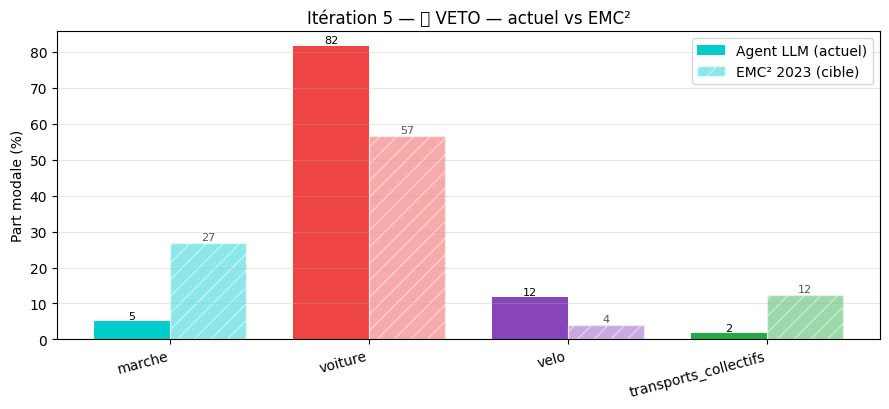

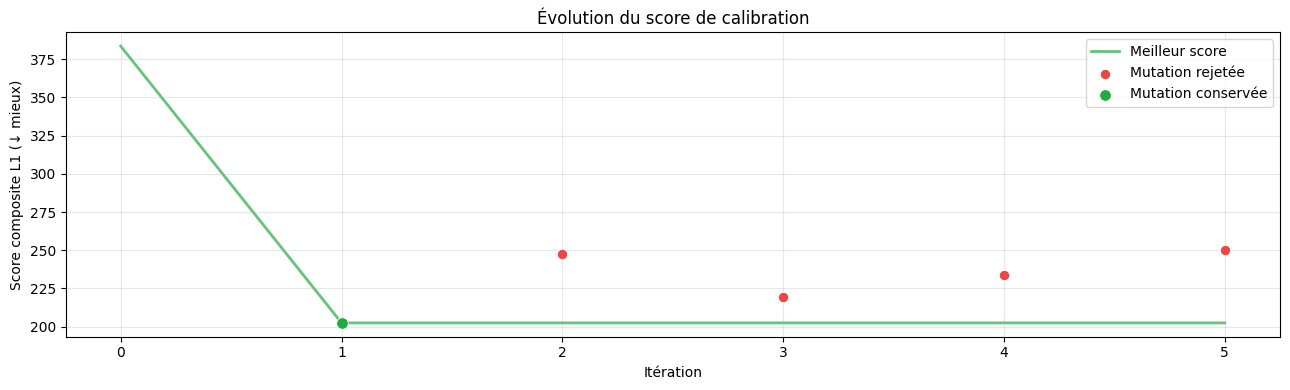


  📊 Évaluation de validation (n=3)…


Validation iter 5:   0%|          | 0/9 [00:00<?, ?it/s]

  📊 Val score: 380.88 ↓  (nouveau meilleur val — train=202.47)
═════════════════════════════════════════════════════════════════
  Itération  6/50  |  Meilleur score : 202.47  |  🏆 All-time best : 202.47  |  T=6.06
═════════════════════════════════════════════════════════════════

── user_msg envoyé au LLM de mutation ──
Distribution LLM actuelle (60 décisions) :
  marche: 5.0%  (cible EMC²: 26%)
  voiture: 81.7%  (cible EMC²: 55%)
  velo: 11.7%  (cible EMC²: 4%)
  transports_collectifs: 1.7%  (cible EMC²: 12%)

Écarts vs EMC² 2023 :
  marche sous-représenté de 21.0 pts
  voiture sur-représenté de 26.7 pts
  velo sur-représenté de 7.7 pts
  transports_collectifs sous-représenté de 10.3 pts

⚠️ DEUX leviers prioritaires (les deux comptent autant) :
  • RENFORCER : marche (actuel=5.0%, cible=26%, manque +21.0 pts)
  • ATTÉNUER  : voiture (actuel=81.7%, cible=55%, excès +26.7 pts)

⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture   

Itération 6:   0%|          | 0/39 [00:00<?, ?it/s]

2026-06-29 12:46:09.719 | WARNING  | llm_module.adapters.google_adapter:call:83 - Timeout de l'API Google | model=gemini-3.1-flash-lite-preview error=_ssl.c:983: The handshake operation timed out


  ⛔ Veto collatéral — dimension(s) dégradée(s) de >15 pts : motif +71

  ⛔ VETO  219.99  (Δ=+17.52  absent_penalty=0  length_penalty=1.8)
    global=54.6  âge=87.8  occupation=85.5  genre=67.5  motif=71.3  distance=69.9

═════════════════════════════════════════════════════════════════
  Itération 6 — ⛔ VETO
═════════════════════════════════════════════════════════════════

CARTE D'ABLATION   vert=utile · rouge=nuisible



⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%, n=50)
  genre[Femme] · marche                 : -22.6 pts (sous-represente, actuel=6% cible=29%, n=50)
  age[75-130] · voiture                : +50.0 pts (sur-represente, actuel=100% cible=50%, n=21)
  occupation[etudiant] · voiture                : +41.8 pts (sur-represente, actuel=60% cible=18%, n=25)
  occupation[etudiant] · transports_collectifs  : -41.4 pts (sous-represente, actuel=0% cible=41%, n=25)
  occupation[Retraité] · voiture                : +43.4 pts (sur-represente, actuel=100% cible=57%, n=21)


★ Score global (composite L1, ↓ mieux) : 202.47

Scores L1 par dimension (↓ mieux, contribution = L1 × poids) :
  global                L1= 65.0  ×1.0  →  65.0  ████████████████████
  age                   L1= 86.9  ×0.5  →  43.4  ████████████████████
  occupation            L1=109.2  ×0.5  →  54.6  ████████

/Users/yvesb/Documents/llm-agents-gama/scripts/models_influence/prompt_calibration_lib.py:1310: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yvesb/Documents/llm-agents-gama/llm-agents/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


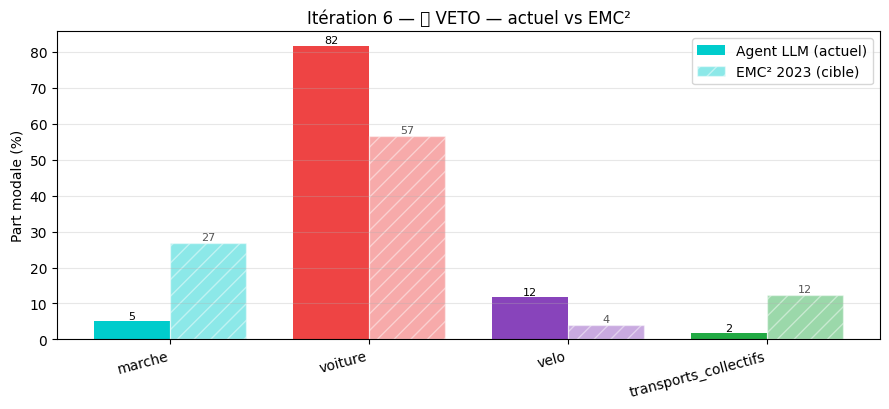

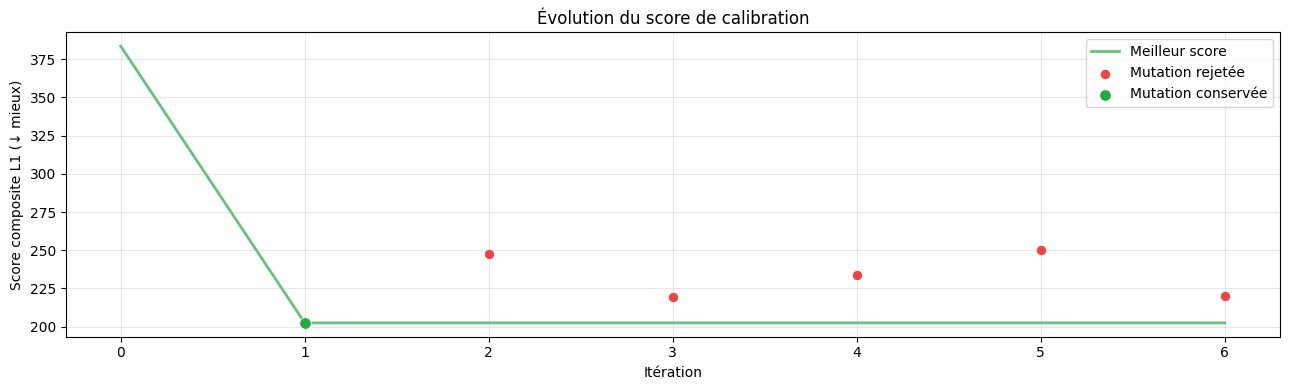

═════════════════════════════════════════════════════════════════
  Itération  7/50  |  Meilleur score : 202.47  |  🏆 All-time best : 202.47  |  T=5.58
═════════════════════════════════════════════════════════════════

── user_msg envoyé au LLM de mutation ──
Distribution LLM actuelle (60 décisions) :
  marche: 5.0%  (cible EMC²: 26%)
  voiture: 81.7%  (cible EMC²: 55%)
  velo: 11.7%  (cible EMC²: 4%)
  transports_collectifs: 1.7%  (cible EMC²: 12%)

Écarts vs EMC² 2023 :
  marche sous-représenté de 21.0 pts
  voiture sur-représenté de 26.7 pts
  velo sur-représenté de 7.7 pts
  transports_collectifs sous-représenté de 10.3 pts

⚠️ DEUX leviers prioritaires (les deux comptent autant) :
  • RENFORCER : marche (actuel=5.0%, cible=26%, manque +21.0 pts)
  • ATTÉNUER  : voiture (actuel=81.7%, cible=55%, excès +26.7 pts)

⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%,

Itération 7:   0%|          | 0/39 [00:00<?, ?it/s]

  Rate limit → 12s
  Rate limit → 9s


2026-06-29 12:52:24.590 | WARNING  | llm_module.adapters.google_adapter:call:83 - Timeout de l'API Google | model=gemini-3.1-flash-lite-preview error=_ssl.c:983: The handshake operation timed out
2026-06-29 12:53:10.357 | WARNING  | llm_module.adapters.google_adapter:call:83 - Timeout de l'API Google | model=gemini-3.1-flash-lite-preview error=_ssl.c:983: The handshake operation timed out


  ⛔ Veto collatéral — dimension(s) dégradée(s) de >15 pts : motif +52, distance +22

  ⛔ VETO  248.67  (Δ=+46.20  absent_penalty=0  length_penalty=1.9)
    global=70.5  âge=101.3  occupation=104.8  genre=77.5  motif=52.2  distance=79.3

═════════════════════════════════════════════════════════════════
  Itération 7 — ⛔ VETO
═════════════════════════════════════════════════════════════════

CARTE D'ABLATION   vert=utile · rouge=nuisible



⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%, n=50)
  genre[Femme] · marche                 : -22.6 pts (sous-represente, actuel=6% cible=29%, n=50)
  age[75-130] · voiture                : +50.0 pts (sur-represente, actuel=100% cible=50%, n=21)
  occupation[etudiant] · voiture                : +41.8 pts (sur-represente, actuel=60% cible=18%, n=25)
  occupation[etudiant] · transports_collectifs  : -41.4 pts (sous-represente, actuel=0% cible=41%, n=25)
  occupation[Retraité] · voiture                : +43.4 pts (sur-represente, actuel=100% cible=57%, n=21)


★ Score global (composite L1, ↓ mieux) : 202.47

Scores L1 par dimension (↓ mieux, contribution = L1 × poids) :
  global                L1= 65.0  ×1.0  →  65.0  ████████████████████
  age                   L1= 86.9  ×0.5  →  43.4  ████████████████████
  occupation            L1=109.2  ×0.5  →  54.6  ████████

/Users/yvesb/Documents/llm-agents-gama/scripts/models_influence/prompt_calibration_lib.py:1310: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yvesb/Documents/llm-agents-gama/llm-agents/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


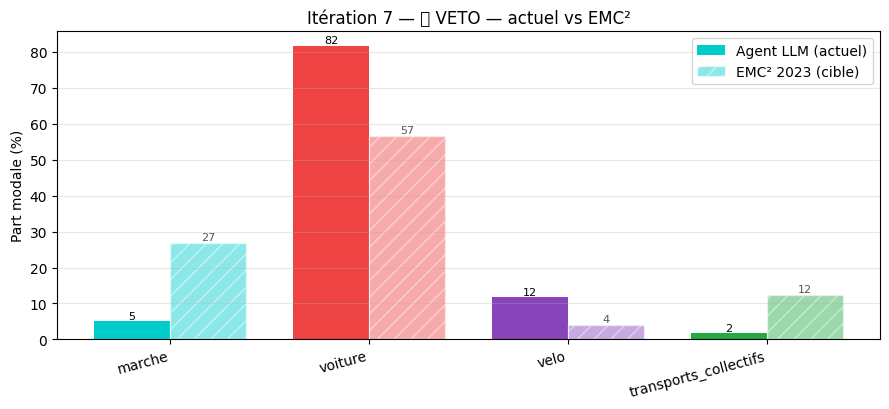

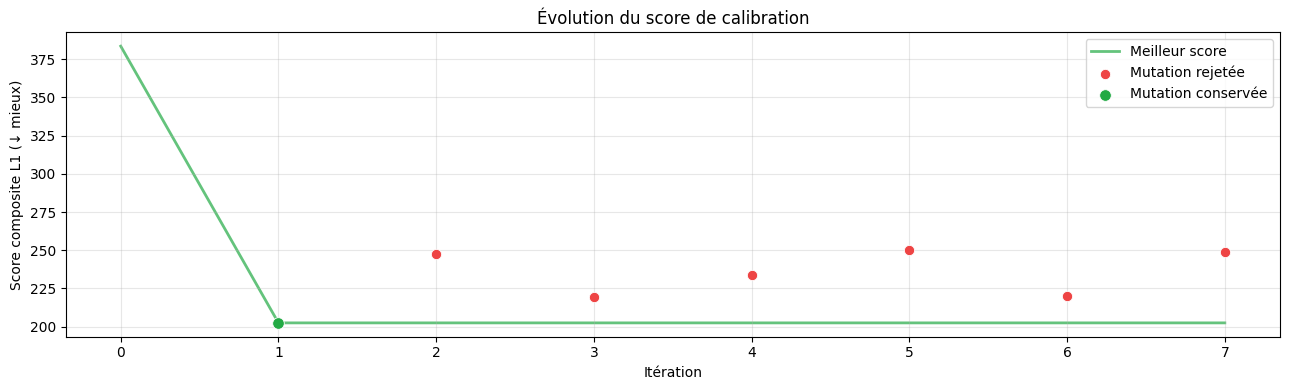

═════════════════════════════════════════════════════════════════
  Itération  8/50  |  Meilleur score : 202.47  |  🏆 All-time best : 202.47  |  T=5.13
═════════════════════════════════════════════════════════════════

── user_msg envoyé au LLM de mutation ──
Distribution LLM actuelle (60 décisions) :
  marche: 5.0%  (cible EMC²: 26%)
  voiture: 81.7%  (cible EMC²: 55%)
  velo: 11.7%  (cible EMC²: 4%)
  transports_collectifs: 1.7%  (cible EMC²: 12%)

Écarts vs EMC² 2023 :
  marche sous-représenté de 21.0 pts
  voiture sur-représenté de 26.7 pts
  velo sur-représenté de 7.7 pts
  transports_collectifs sous-représenté de 10.3 pts

⚠️ DEUX leviers prioritaires (les deux comptent autant) :
  • RENFORCER : marche (actuel=5.0%, cible=26%, manque +21.0 pts)
  • ATTÉNUER  : voiture (actuel=81.7%, cible=55%, excès +26.7 pts)

⚠️ Pires ecarts strate x mode (actuel vs cible EMC2, impact |Δ|×n decroissant) :
  genre[Femme] · voiture                : +24.9 pts (sur-represente, actuel=80% cible=55%,

Itération 8:   0%|          | 0/39 [00:00<?, ?it/s]

In [ ]:
BEST_CHECKPOINT     = RESULTS_DIR / "best_checkpoint.yaml"
MUTATION_CACHE_FILE = RESULTS_DIR / "mutations.jsonl"
# Journal des mutations LLM (temp 0.8 → non reproductible) indexé par itération.
# Au redémarrage il est rechargé : chaque itération déjà jouée retrouve SA mutation
# sans appel LLM, et la boucle (déterministe) rejoue exactement la même trajectoire.
mutation_cache = mutation_cache_load(MUTATION_CACHE_FILE)
if mutation_cache:
    print(f"↺ {len(mutation_cache)} mutation(s) retrieved from previous session "
          f"(itérations {min(mutation_cache)}–{max(mutation_cache)})")


def save_checkpoint(blocks: list[dict], score: float, iteration: int) -> None:
    """Écrase le checkpoint avec le meilleur prompt courant."""
    data = {
        "content": blocks_to_prompt(blocks),
        "_calibration": {
            "seed":          SEED_PROMPT,
            "iteration":     iteration,
            "score_initial": float(round(history[0]["best_score"], 2)) if history else None,
            "score_best":    float(round(score, 2)),
            "saved_at":      datetime.now().isoformat(timespec="seconds"),
        },
    }
    with open(BEST_CHECKPOINT, "w") as f:
        yaml.dump(data, f, allow_unicode=True, default_flow_style=False, sort_keys=False)
    print(f"  💾 Checkpoint → {BEST_CHECKPOINT.name}  (score={score:.2f}, iter={iteration})")


# ── État du run ───────────────────────────────────────────────────────────────
accepted_count  = 0
val_best_score  = float("inf")
val_no_improve  = 0

MAX_ITERATIONS = 50
for iteration in range(1, MAX_ITERATIONS + 1):
    temperature = SA_T0 * (SA_ALPHA ** iteration)

    print(f"{'═'*65}")
    print(f"  Itération {iteration:>2}/{MAX_ITERATIONS}  |  Meilleur score : {best_score:.2f}  |  "
          f"🏆 All-time best : {all_time_best_score:.2f}  |  T={temperature:.2f}")
    print(f"{'═'*65}")

    # 1. Générer une mutation — ou la rejouer depuis le journal ────────────────
    if iteration in mutation_cache:
        mutation = mutation_cache[iteration]
        print("  ↺ mutation retrieved from previous session "
              f"(bloc={mutation.get('target_block') if mutation else None})")
    else:
        try:
            mutation = generate_mutation(best_blocks, best_df, best_score, history,
                                         ablation_results=ablation_init,
                                         dim_scores=best_scores)
        except Exception as exc:
            print(f"  ⚠ Erreur mutation : {exc}")
            history.append({"iteration": iteration, "scores": {"composite": best_score, "absent_penalty": 0.0},
                            "best_score": all_time_best_score, "kept": False, "mutation": None, "prompt": None})
            continue
        mutation_cache_append(MUTATION_CACHE_FILE, iteration, mutation)
        mutation_cache[iteration] = mutation

    print(f"\n  Mutation proposée :")
    print(f"    Bloc   : {mutation.get('target_block')}")
    print(f"    Action : {mutation.get('action')}")
    print(f"    Raison : {mutation.get('rationale')}")
    if mutation.get("action") in ("modify", "insert"):
        nc = mutation.get("new_content", "")
        print(f"    Contenu: {nc[:120]}{'…' if len(nc) > 120 else ''}")

    # 2. Appliquer la mutation ────────────────────────────────────────────────
    old_names      = {b["name"] for b in best_blocks}
    mutated_blocks = apply_mutation(best_blocks, mutation)
    if mutated_blocks is None:
        print("  ⏭ Mutation invalide, itération ignorée")
        history.append({"iteration": iteration, "scores": {"composite": best_score, "absent_penalty": 0.0},
                        "best_score": all_time_best_score, "kept": False, "mutation": mutation, "prompt": None})
        continue
    inserted_names = {b["name"] for b in mutated_blocks} - old_names

    # 3. Évaluer le nouveau prompt sur le jeu train ───────────────────────────
    mutated_prompt = blocks_to_prompt(mutated_blocks)
    df_run         = run_evaluation(train_entries, mutated_prompt, METADATA_CACHE,
                                    desc=f"Itération {iteration}")
    run_scores     = compute_composite_score(df_run, cerema, prompt_text=mutated_prompt)
    composite      = run_scores["composite"]

    # 3b. Garde-fou anti-dégâts collatéraux (#8) ──────────────────────────────
    # Une mutation peut faire baisser le composite via 'global' tout en faisant
    # exploser une autre dimension (ex : une poussée pro-marche qui ruine 'motif').
    # On oppose un veto si une dimension non-globale se dégrade de plus de COLLATERAL_TOL.
    _GUARDED_DIMS = ["age", "occupation", "genre", "motif", "distance"]
    collateral = []
    if best_scores:
        collateral = [(d, run_scores.get(d, 0) - best_scores.get(d, 0)) for d in _GUARDED_DIMS
                      if run_scores.get(d, 0) - best_scores.get(d, 0) > COLLATERAL_TOL]
    vetoed = bool(collateral)
    if vetoed:
        dmg = ", ".join(f"{d} +{v:.0f}" for d, v in collateral)
        print(f"  ⛔ Veto collatéral — dimension(s) dégradée(s) de >{COLLATERAL_TOL:.0f} pts : {dmg}")

    # 4. Sauvegarde du meilleur score toutes itérations confondues ────────────
    if composite < all_time_best_score and not vetoed:
        all_time_best_score  = composite
        all_time_best_blocks = mutated_blocks
        all_time_best_df     = df_run
        save_checkpoint(all_time_best_blocks, all_time_best_score, iteration)
        print(f"  🏆 Nouveau meilleur score toutes itérations : {all_time_best_score:.2f}")

    # 5. Garder ou annuler — veto collatéral, puis simulated annealing ─────────
    delta = composite - best_score
    if vetoed:
        accept      = False
        verdict_tag = "⛔ VETO"
    elif delta < 0:
        accept      = True
        verdict_tag = "✅ AMÉLIORÉ"
    elif temperature > 0.5 and delta < temperature:
        accept      = True
        verdict_tag = "🌡 SA-ACCEPTÉ"
    else:
        accept      = False
        verdict_tag = "↩  REJETÉ"

    if accept:
        accepted_count += 1
        best_score, best_blocks, best_df = composite, mutated_blocks, df_run
        best_scores = run_scores   # màj du dict de scores pour la prochaine mutation
        target_name = mutation.get("target_block")
        action      = mutation.get("action", "modify")

        # ── Mise à jour LOCALE de l'ablation ─────────────────────────────────
        if action == "delete":
            print(f"  ↻ Bloc {target_name!r} supprimé — retrait de l'ablation")
            ablation_init = [r for r in ablation_init if r["bloc"] != target_name]
        else:
            blocks_to_update = list(inserted_names) if action == "insert" else [target_name]
            for bname in blocks_to_update:
                tgt = next((b for b in best_blocks if b["name"] == bname), None)
                if not (tgt and tgt["mutable"]):
                    continue
                ablated        = [b for b in best_blocks if b["name"] != bname]
                ablated_prompt = blocks_to_prompt(ablated)
                df_abl         = run_evaluation(train_entries, ablated_prompt,
                                                METADATA_CACHE, desc=f"Ablation [{bname}]")
                abl_scores = compute_composite_score(df_abl, cerema, prompt_text=ablated_prompt)
                new_result = build_ablation_result(
                    bname, tgt["content"], abl_scores, best_score,
                    ref_scores=best_scores, abl_df=df_abl, ref_df=best_df, cerema=cerema,
                )
                abl_delta   = new_result["delta"]
                verdict_abl = ("🔑 UTILE" if abl_delta > 2
                               else "🗑  NUISIBLE" if abl_delta < -2 else "≈  neutre")
                suffix  = " [nouveau]" if bname in inserted_names else ""
                preview = tgt["content"].replace("\n", " ")
                print(f"  {bname:22s}  Δ={abl_delta:+7.2f}  {verdict_abl}{suffix}")
                if new_result["diag"]:
                    print(f"    ↳ régression : {new_result['diag']}")
                print(f"    ↳ {preview[:110]}{'…' if len(tgt['content']) > 110 else ''}")
                ablation_init = sorted(
                    [r for r in ablation_init if r["bloc"] != bname] + [new_result],
                    key=lambda r: r["delta"], reverse=True,
                )

        # ── Recalcul GLOBAL de l'ablation toutes les GLOBAL_ABLATION_EVERY mutations acceptées ──
        if accepted_count % GLOBAL_ABLATION_EVERY == 0:
            print(f"\n  🔄 Recalcul global de l'ablation (accepted={accepted_count})…")
            ablation_init = run_ablation(
                best_blocks, train_entries, METADATA_CACHE, cerema,
                best_score, ref_scores=best_scores, ref_df=best_df,
                label=f"Global ablation (accepted={accepted_count})",
            )

    verdict = (f"{verdict_tag}  {composite:.2f}  "
               f"(Δ={delta:+.2f}  absent_penalty={run_scores['absent_penalty']:.0f}  "
               f"length_penalty={run_scores['length_penalty']:.1f})")
    print(f"\n  {verdict}")
    print(f"    global={run_scores['global']:.1f}  âge={run_scores['age']:.1f}  "
          f"occupation={run_scores['occupation']:.1f}  genre={run_scores['genre']:.1f}  "
          f"motif={run_scores['motif']:.1f}  distance={run_scores['distance']:.1f}")

    history.append({"iteration": iteration, "scores": run_scores,
                    "best_score": all_time_best_score, "kept": accept,
                    "mutation": mutation,
                    "prompt": mutated_prompt if accept else None})

    # ── Tableau de bord de présentation — à CHAQUE mutation (acceptée ou rejetée) ──
    # Carte d'ablation + méta (pires écarts strate × mode) + score global + scores L1
    # + barres actuel vs EMC² (hachuré) + évolution du score (vert=conservé, rouge=rejeté).
    present_calibration_state(
        best_blocks, ablation_init, best_df, best_scores,
        history=history, title=f"Itération {iteration} — {verdict_tag}",
    )

    # ── Visualisation + Validation + Early Stopping ───────────────────────────
    if iteration % 5 == 0:
        print(f"\n  📊 Évaluation de validation (n={len(val_entries)})…")
        df_val     = run_evaluation(val_entries, blocks_to_prompt(all_time_best_blocks),
                                    METADATA_CACHE, desc=f"Validation iter {iteration}")
        val_prompt = blocks_to_prompt(all_time_best_blocks)
        val_scores = compute_composite_score(df_val, cerema, prompt_text=val_prompt)
        val_comp   = val_scores["composite"]

        if val_comp < val_best_score:
            val_best_score = val_comp
            val_no_improve = 0
            print(f"  📊 Val score: {val_comp:.2f} ↓  (nouveau meilleur val — train={all_time_best_score:.2f})")
        else:
            val_no_improve += 1
            print(f"  📊 Val score: {val_comp:.2f}  "
                  f"(best_val={val_best_score:.2f}, no_improve={val_no_improve}/{EARLY_STOP_PATIENCE})")

        if val_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\n  🛑 Early stopping — pas d'amélioration val sur {EARLY_STOP_PATIENCE} checks "
                  f"({EARLY_STOP_PATIENCE * 5} itérations consécutives).")
            break

print("\n✅ Calibration terminée.")

## 7 · Résultats finaux

Comparaison score initial / meilleur SA / meilleur absolu, distribution initiale vs finale, et détail multi-dimensionnel du meilleur prompt.

In [ ]:
print("═" * 65)
print("RÉSULTATS FINAUX")
print(f"  Score initial      : {history[0]['best_score']:.2f}")
print(f"  Meilleur SA score  : {best_score:.2f}  (état SA final)")
print(f"  🏆 Meilleur absolu : {all_time_best_score:.2f}  (toutes itérations)")
n_improved = sum(1 for h in history if h["kept"] and h["iteration"] > 0)
print(f"  Améliorations SA   : {n_improved} / {MAX_ITERATIONS}")
print("═" * 65)

plot_score_history(history)

# Comparaison initiale vs finale côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cerema_g = {k: v for k, v in cerema["parts_modales_2023"]["global"].items()
            if k not in EXCLUDE_MODES}
ref_series = pd.Series(cerema_g).reindex(MODES).fillna(0)
ref_series = ref_series / ref_series.sum() * 100

for ax, df_plot, title in [(axes[0], df_init, "Initial (persona_v1)"),
                            (axes[1], all_time_best_df, f"🏆 Meilleur prompt (score={all_time_best_score:.2f})")]:
    llm_s = df_plot["mode_cat"].value_counts().reindex(MODES).fillna(0)
    llm_s = llm_s / llm_s.sum() * 100
    x = range(len(MODES))
    bars1 = ax.bar([i - 0.2 for i in x], llm_s, width=0.35,
                    color=[MODE_COLORS[m] for m in MODES], alpha=0.9, label="LLM")
    bars2 = ax.bar([i + 0.2 for i in x], ref_series, width=0.35,
                    color=[MODE_COLORS[m] for m in MODES], alpha=0.4,
                    hatch="///", label="EMC² 2023")
    ax.set_xticks(list(x))
    ax.set_xticklabels(MODES, rotation=20, ha='right')
    ax.set_ylabel("%")
    ax.set_ylim(0, 75)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

# Détail multi-dimensionnel du meilleur prompt
plot_bars_by_dimension(all_time_best_df, "Meilleur prompt — comparaison par dimension")

# Prompt final
print("\n" + "═" * 65)
print("🏆 MEILLEUR PROMPT (toutes itérations) :")
print("═" * 65)
display_blocks(all_time_best_blocks)


## 8 · Sauvegarde du meilleur prompt & historique

Écriture du meilleur prompt dans `prompts.yaml` (clé horodatée) et export de l'historique des scores en CSV.

In [ ]:
# ── Sauvegarder le meilleur prompt dans prompts.yaml ───────────────────────
best_prompt_text = blocks_to_prompt(all_time_best_blocks)
calib_key = f"calibrated_{datetime.now().strftime('%Y%m%d_%H%M')}"

with open(PROMPTS_FILE) as f:
    prompts_yaml = yaml.safe_load(f)

prompts_yaml["prompts"][calib_key] = {
    "content": best_prompt_text,
    "_calibration": {
        "seed":           SEED_PROMPT,
        "iterations":     MAX_ITERATIONS,
        "sample_size":    SAMPLE_SIZE,
        "score_initial":  float(round(history[0]["best_score"], 2)),
        "score_final":    float(round(all_time_best_score, 2)),
        "date":           datetime.now().isoformat()[:10],
    },
}

with open(PROMPTS_FILE, "w") as f:
    yaml.dump(prompts_yaml, f, allow_unicode=True, default_flow_style=False, sort_keys=False)

print(f"✅ Prompt sauvegardé sous la clé : {calib_key!r}")
print(f"   Score all-time best : {all_time_best_score:.2f}")

# Historique CSV
hist_rows = []
for h in history:
    row = {
        "iteration":      h["iteration"],
        "composite":      h["scores"]["composite"],
        "global":         h["scores"].get("global", 0),
        "absent_penalty": h["scores"].get("absent_penalty", 0),
        "age":            h["scores"].get("age", 0),
        "occupation":     h["scores"].get("occupation", 0),
        "best_score":     h["best_score"],
    }
    if h["mutation"]:
        row.update({
            "target_block": h["mutation"].get("target_block"),
            "action":       h["mutation"].get("action"),
            "rationale":    h["mutation"].get("rationale"),
        })
    hist_rows.append(row)

hist_df = pd.DataFrame(hist_rows)
hist_df.to_csv(RESULTS_DIR / "calibration_history.csv", index=False)
print(f"📊 Historique → {RESULTS_DIR / 'calibration_history.csv'}")


## 9 · Diff prompt initial → calibré

Diff mot à mot façon git entre le prompt de départ et le meilleur prompt calibré.

In [ ]:
# Diff git-like prompt initial → calibré — fonctions dans prompt_calibration_lib.py
import difflib
from IPython.display import HTML

initial_text = blocks_to_prompt(initial_blocks)
best_text    = blocks_to_prompt(best_blocks)

diff_lines = list(difflib.unified_diff(
    initial_text.splitlines(keepends=True),
    best_text.splitlines(keepends=True),
    fromfile=f"prompt initial ({SEED_PROMPT})",
    tofile=f"meilleur prompt calibré  [score {best_score:.2f}]",
    lineterm="",
))

print("═" * 65)
print("DIFF PROMPT INITIAL → MEILLEUR PROMPT CALIBRÉ  (diff mot à mot)")
print("═" * 65)

if diff_lines:
    display(HTML(render_diff_html(diff_lines)))
    n_add = sum(1 for l in diff_lines if l.startswith("+") and not l.startswith("+++"))
    n_del = sum(1 for l in diff_lines if l.startswith("-") and not l.startswith("---"))
    print(f"  +{n_add} lignes ajoutées / -{n_del} lignes supprimées")
else:
    print("  Aucune différence — le prompt n'a pas évolué.")


## 10 · Carte d'ablation du meilleur prompt

In [ ]:
print("═" * 65)
print("🏆 MEILLEUR PROMPT — carte d'ablation  (vert=utile · rouge=nuisible)")
print("═" * 65)
highlight_prompt_ablation(all_time_best_blocks, ablation_init)
